In [66]:
import math
import time
from typing import List
from pathlib import Path
import os
import sys
from math import pi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import sobel, gaussian_filter
from scipy.interpolate import UnivariateSpline
from scipy.signal import find_peaks
from scipy.optimize import curve_fit


from chars import greek, phys

In [67]:
N=75

cwd = Path(os.getcwd())

# results_dir = cwd / "WS2_Grating_Eamonn" / "Results" / 'WS₂, SiO₂, Si' / 't=18.0nm Λ=500nm FF=0.84 N=75' / 'data'
# results_dir = cwd / "WS2_Grating_Eamonn" / "Results" / 'WS₂, SiO₂, Si 4' / 't=60.0nm Λ=350nm FF=0.55 N=75' / 'data'
results_dir = cwd / "WS2_Grating_Eamonn" / "Results" / 'WS₂, SiO₂, Si' / 't=38.0nm Λ=500nm FF=0.76 N=75' / 'data'


savepath = cwd / 'mode_fitting'
savepath.mkdir(exist_ok=True, parents=True)


files = sorted(os.listdir(results_dir))
file_R = results_dir / files[4]
file_R_sub = results_dir / files[5]
print(file_R)

R = pd.read_csv(file_R, index_col=0)
Rsub = pd.read_csv(file_R_sub, index_col=0)

signalR = (R - Rsub) / Rsub
signalR = (signalR - np.min(signalR)) / (np.max(signalR) - np.min(signalR))





C:\Users\whamp\PycharmProjects\research_project\WS2_Grating_Eamonn\Results\WS₂, SiO₂, Si\t=38.0nm Λ=500nm FF=0.76 N=75\data\WS₂, SiO₂, Si - t=38.0nm Λ=500nm FF=0.76_R_sub.csv


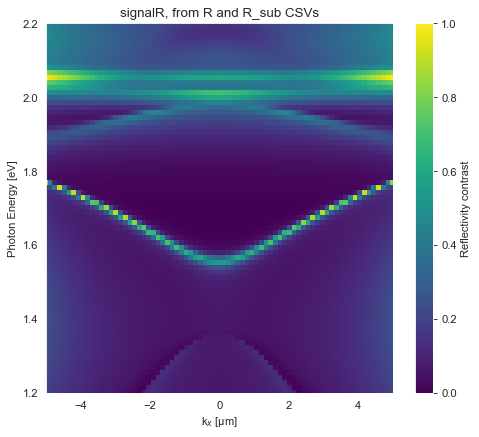

In [68]:
N=75
ev_wav_factor = 1.24
lbda_min = 2.2  # y limits in micrometers
lbda_max = 1.2
lbda = np.linspace(lbda_min, lbda_max, N)  # Generate wavelengths in micrometers

N_k=N
# k_scan=np.linspace(-6.7,6.7,N_k) #mu-1
kmax=5
k_scan=np.linspace(-kmax,kmax,N_k) #mu-1
ky=0.000
title_name = 'signalR, from R and R_sub CSVs'

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,lbda,signalR,cmap='viridis',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',
        xlim=(-kmax,kmax),ylim=(lbda_max, lbda_min), 
        ylabel='Photon Energy [eV]',
        title=title_name)
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()

(75, 75)


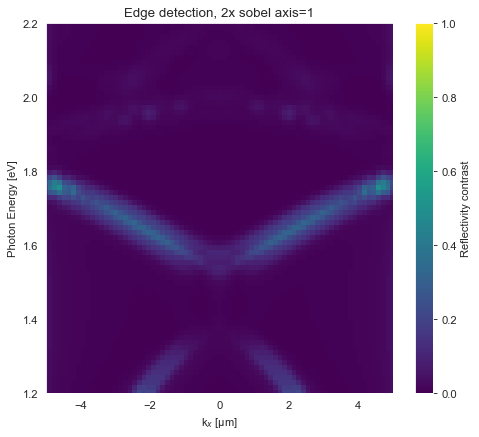

In [69]:

data_array = np.asarray(signalR)
sobel_x = sobel(data_array, axis=0)  # Sobel in the x-direction
sobel_y = sobel(data_array, axis=1)  # Sobel in the y-direction

sobel_y = sobel(sobel_y, axis=1)  # Sobel in the y-direction

# Calculate the gradient magnitude (combined Sobel in x and y)
sobel_magnitude = np.hypot(sobel_x, sobel_y)

edge_magnitude = np.abs(sobel_y)

# Normalize edge magnitude for better visualization
edge_magnitude_normalized = edge_magnitude / np.max(edge_magnitude)

# Apply Gaussian blur to smooth the edges (adjust sigma as needed for desired blur amount)
sigma = 0.8
edge_magnitude_blurred = gaussian_filter(edge_magnitude_normalized, sigma=sigma)


print(edge_magnitude.shape)

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,lbda,edge_magnitude_blurred,cmap='viridis',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(lbda_max, lbda_min), ylabel='Photon Energy [eV]',title='Edge detection, 2x sobel axis=1')
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()
plt.savefig(savepath / 'edgedetect_gaussian.png', dpi=150)
plt.show()



PEAKS: [11 19 36 40 58]
PEAKS: [36 40]
TROUGHS: [ 6 14 27 39 55 60]
TROUGHS: [ 6 14 27 55 60]
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Peak at 36 - before=27, after=55, diff 0.008264794749661197
Peak at 40 - before=27, after=55, diff 0.006666986776430591
Found peak at idx 36


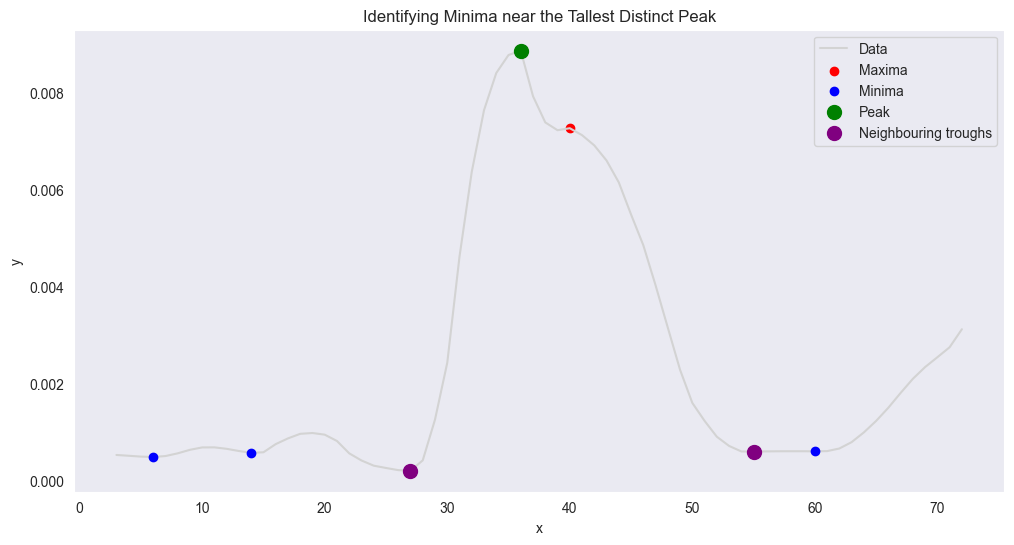

In [79]:
# find the coords of above and below the top mode, identify the gap
line_y_max = [np.max(row)*np.mean(row)/np.sum(row) for row in edge_magnitude_normalized]


pd_line_y_max = pd.Series(line_y_max)

# Apply a 3-point moving average to smooth the data
pd_line_y_max_plottinged = pd_line_y_max.rolling(window=6, center=True).mean()


# Use the Series index as x values
y = pd_line_y_max_plottinged
x = pd_line_y_max_plottinged.index

y_min, y_max = y.min(), y.max()
# Define thresholds
trough_threshold = y_min + 0.5 * (y_max - y_min)  # Troughs must be below halfway
peak_threshold = y_min + 0.8 * (y_max - y_min)   # Peaks must be above 80%

# Filter peaks and troughs based on thresholds
peaks, _ = find_peaks(y)
print(f"PEAKS: {peaks}")
peaks = np.array([int(p) for p in peaks if y[p] >= peak_threshold])  # Keep only valid peaks
print(f"PEAKS: {peaks}")

troughs, _ = find_peaks(-y)  # Invert y to find minima

print(f"TROUGHS: {troughs}")
troughs = np.array([int(t) for t in troughs if y[t] <= trough_threshold])  # Keep only valid troughs
print(f"TROUGHS: {troughs}")

print(type(troughs), type(peaks))
# peaks_df = pd.Series(peaks)
# troughs_df = pd.Series(troughs)
# pt_df = pd.DataFrame({'peaks':peaks_df, 'troughs':troughs_df})
# print(pt_df)

minima_indices = troughs
min_peak_trough_diff = 0.6

max_peak = None # [loc, comparable diff]
min_troughs = None # [loc1, loc2]

for _,peak in enumerate(peaks):
    before_trough = troughs[troughs < peak].max() if (troughs < peak).any() else None
    after_trough = troughs[troughs > peak].min() if (troughs > peak).any() else None
    
    if None in [before_trough, after_trough]:
        continue
    before_trough = int(before_trough)
    after_trough = int(after_trough)
    
    diff1, diff2 = y[peak] - y[before_trough], y[peak] - y[after_trough]
    diff_min = np.min([diff1, diff2]) # find min proximity in y to trough
    
    if max_peak == None or max_peak[1] < diff_min:
        max_peak = [peak,diff_min]
        min_troughs = [before_trough, after_trough]
    
    print(f"Peak at {peak} - before={before_trough}, after={after_trough}, diff {diff_min}")

print(f"Found peak at idx {max_peak[0]}")
    


# Step 5: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Data', color='lightgray')
plt.scatter(x[peaks], y[peaks], color='red', label='Maxima')
plt.scatter(x[minima_indices], y[minima_indices], color='blue', label='Minima', zorder=5)
plt.scatter(x[max_peak[0]], y[max_peak[0]], color='green', label='Peak', s=100, zorder=10)
plt.scatter([x[min_troughs[0]], x[min_troughs[1]]], [y[min_troughs[0]], y[min_troughs[1]]], color='purple', label='Neighbouring troughs', s=100, zorder=10)
plt.title('Identifying Minima near the Tallest Distinct Peak')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()

plt.savefig(savepath / 'peaks.png', dpi=150)
plt.show()


(75,) (75,)


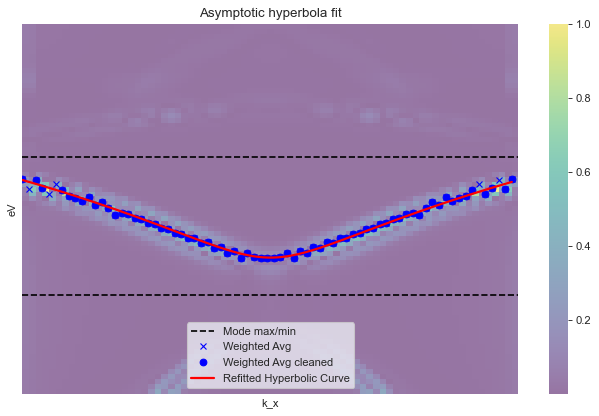

Fitted parameters (cleaned hyperbolic):
a = 0.0078, b = 58.9423, L = 6842.1570, M = 0.5011, F = 125.2875, B = 0.0593, V = 5.7971


RMSE: 0.5700561948078725, R^2: 0.9870092023326436
EVALUATING 0.9870 vs 0.60
WELL FITTED
(45,) (45,)


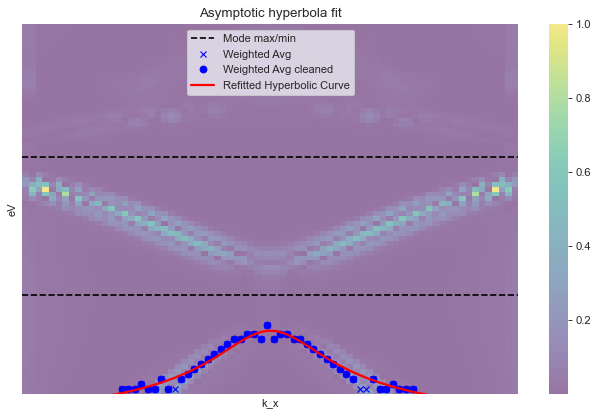

Fitted parameters (cleaned hyperbolic):
a = -0.1161, b = 3.4707, L = 6964.9351, M = 0.5747, F = 134.8394, B = 0.2674, V = 2.0898


RMSE: 0.984287533530252, R^2: 0.9482002311336878
EVALUATING 0.9482 vs 0.60
WELL FITTED
2 modes present and well fitted
{'0': {'R2': np.float64(0.9870092023326436), 'popt': array([7.79818934e-03, 5.89422921e+01, 6.84215697e+03, 5.01064534e-01,
       1.25287543e+02, 5.93376159e-02, 5.79713778e+00, 4.91617435e-04])}, '1': {'R2': np.float64(0.9482002311336878), 'popt': array([-1.16148585e-01,  3.47070035e+00,  6.96493510e+03,  5.74706524e-01,
        1.34839407e+02,  2.67430443e-01,  2.08980737e+00,  9.99994510e-01])}}


In [91]:

# Define the hyperbolic asymptotic model for curve fitting
def hyperbola_asymptotic_u(x, a, b, L, M, F, B, V, c):
    """
    Hyperbolic asymptotic fit model
    :param x: x
    :param a: shift y
    :param b: shift x (redundant, =N/2)
    :param L: multiply y
    :param M: multiply x
    :param F: pointyness
    :param B: asymptote in y
    :param sign: u or n shape (redundant)
    :return: g(x) func result
    """
    sign = -1 * c
    xbM = ((x - 37.5) ** 2) / M
    f_x = sign*np.sqrt(np.abs( (F + xbM) ))
    g_x = a + ( f_x / (V*( 1 + (np.abs(f_x) / B) )) )
    return g_x * L

def hyperbola_asymptotic_n(x, a, b, L, M, F, B, V, c):
    """
    Hyperbolic asymptotic fit model
    :param x: x
    :param a: shift y
    :param b: shift x (redundant, =N/2)
    :param L: multiply y
    :param M: multiply x
    :param F: pointyness
    :param B: asymptote in y
    :param sign: u or n shape (redundant)
    :return: g(x) func result
    """
    sign = 1 * c
    xbM = ((x - 37.5) ** 2) / M
    f_x = sign*np.sqrt(np.abs( (F + xbM) ))
    g_x = a + ( f_x / (V*( 1 + (np.abs(f_x) / B) )) )
    return g_x * L

hyperbolas = [hyperbola_asymptotic_u, hyperbola_asymptotic_n]

fitting_data = {}

def process_fitting(iteration, y_min, y_max, sign):
    hyperbola_asymptotic = hyperbolas[iteration] # decide u or n shape
    
    # Create a heatmap (visualization)
    plt.figure(figsize=(10, 6), dpi=80)
    sns.heatmap(edge_magnitude_normalized, cmap='viridis', xticklabels=False, yticklabels=False, alpha=0.5)
    
    # Add horizontal lines at the minimum troughs
    plt.axhline(y=min_troughs[0], color='black', linestyle='--', label='Mode max/min')
    plt.axhline(y=min_troughs[1], color='black', linestyle='--')
    
    # Extract the region of interest between the minimum troughs
    
    data_region = edge_magnitude_normalized[y_min:y_max, :]
    x_indices = np.arange(data_region.shape[1])
    
    # Calculate weighted average energy positions for the top 25 quantile values
    y_positions = []
    for x in x_indices:
        column = data_region[:, x]
        y_indices = np.arange(len(column))
    
        quantile_threshold = np.percentile(column, 95)
        filtered_indices = np.where(column >= quantile_threshold)[0]
        filtered_column = column[filtered_indices]
        filtered_y_indices = y_indices[filtered_indices]
    
        if np.sum(filtered_column) > 0:
            weighted_avg = np.sum(filtered_column * filtered_y_indices) / np.sum(filtered_column)
            y_positions.append(weighted_avg + y_min)
        else:
            y_positions.append((y_max + y_min) / 2)
    
    x_data = np.array(x_indices)
    y_data = np.array(y_positions)
    
    if len(y_data) % 2 == 1:  # Odd number of points
        central_value = y_data[len(y_data) // 2]
    else:  # Even number of points, use average of the two middle values
        mid_idx = len(y_data) // 2
        central_value = np.max([y_data[mid_idx - 1], y_data[mid_idx]])
    
    # Remove data points greater than the central value
    if iteration == 0:
        mask = y_data <= central_value
        x_data = x_data[mask]
        y_data = y_data[mask]
    elif iteration == 1:
        mask = y_data >= central_value
        x_data = x_data[mask]
        y_data = y_data[mask]
    
    print(np.shape(y_data), np.shape(x_data))
    
    
    
    initial_guess = \
        [0.3, N / 2, 7000, 0.6, 500, 0.3, 5, 0.1] # a = 0.0797, b = 37.5000, L = 6999.9990, M = 0.6000, F = 500.0000, B = 0.3863, V = 4.9998, c=0.1
    bounds = \
        ([-50, 0, 100, 0.5, 1, 0, 1, -1], 
         [50, N, 10000, 10, 10000, 100, 20, 1])
    
    # Perform hyperbolic curve fitting
    popt, pcov = curve_fit(f=hyperbola_asymptotic, xdata=x_data, ydata=y_data, p0=initial_guess, bounds=bounds, maxfev=10000)
    
    # Generate smooth x-values for plotting the fitted hyperbolic curve
    x_plotting = np.linspace(0, data_region.shape[1] - 1, 300)
    y_fit = hyperbola_asymptotic(x_plotting, *popt)
    
    # Calculate residuals and identify outliers
    residuals = y_data - hyperbola_asymptotic(x_data, *popt)
    threshold = 2 * np.std(residuals)
    outlier_indices = np.abs(residuals) > threshold
    x_data_cleaned = x_data[~outlier_indices]
    y_data_cleaned = y_data[~outlier_indices]
    
    
    initial_guess_2 = popt
    
    # Refit the hyperbolic model to the cleaned data
    popt_cleaned, pcov_cleaned = curve_fit(hyperbola_asymptotic, x_data_cleaned, y_data_cleaned, p0=initial_guess_2, bounds=bounds, maxfev=10000)
    y_fit_cleaned = hyperbola_asymptotic(x_plotting, *popt_cleaned)
    # print(f"PCOV cleaned: {pcov_cleaned}")
    
    # Overlay the data and the fitted hyperbolic curve on the heatmap
    plt.plot(x_data, y_data, 'bx', markersize=6, label='Weighted Avg')
    plt.plot(x_data_cleaned, y_data_cleaned, 'bo', markersize=6, label='Weighted Avg cleaned')
    # plt.plot(x_plotting, y_fit, 'r--', linewidth=2, label='Initial Fit')
    plt.plot(x_plotting, y_fit_cleaned, 'r-', linewidth=2, label='Refitted Hyperbolic Curve')
    
    
    
    # Configure the plot
    plt.xlabel('k_x')
    plt.ylabel('eV')
    if iteration == 0:
        plt.legend(loc='lower center')
    if iteration == 1:
        plt.legend(loc='upper center')
    plt.minorticks_on()
    plt.title('Asymptotic hyperbola fit')
    plt.savefig(savepath / f'Fitted {iteration}.png', dpi=150)
    plt.show()
    
    a_cleaned, b_cleaned, L_cleaned, M_cleaned, F_cleaned, B_cleaned, V_cleaned, ex = popt_cleaned
    print(f"Fitted parameters (cleaned hyperbolic):\na = {a_cleaned:.4f}, b = {b_cleaned:.4f}, L = {L_cleaned:.4f}, M = {M_cleaned:.4f}, F = {F_cleaned:.4f}, B = {B_cleaned:.4f}, V = {V_cleaned:.4f}")
    
    
    residuals = y_data - hyperbola_asymptotic(x_data, *popt_cleaned)
    rmse = np.sqrt(np.mean(residuals**2))
    ss_total = np.sum((y_data - np.mean(y_data))**2)
    ss_residual = np.sum(residuals**2)
    r2 = 1 - (ss_residual / ss_total)
    print(f"\n\nRMSE: {rmse}, R^2: {r2}")
    
    fitting_data[str(iteration)] = {'R2':r2, 'popt':popt_cleaned}
    
    print(f"EVALUATING {abs(r2):.4f} vs {r2_threshold:.2f}")
    if float(abs(r2)) > float(r2_threshold):
        print("WELL FITTED")
        return 1
    else:
        return 0



# y_min, y_max = min_troughs[1], None
# y_min, y_max = min_troughs[0], min_troughs[1]
if len(min_troughs) == 2:
    min_troughs.append(None)
    print(min_troughs)

results = []
r2_threshold = 0.6
for i in range(0, 2):
    # print(i)
    y_min, y_max = min_troughs[i], min_troughs[i+1]
    sign = 2*i - 1
    result = process_fitting(i, y_min, y_max, sign)
    if result == 1:
        results.append(result)

if len(results) == 2:
    print("2 modes present and well fitted")
else:
    print(f"2 modes not present - {len(results)} modes fitted")
    
    
    
print(fitting_data)




Upper mode (sign -)
Vertex - 1.568
Asymptote - 2.422

Upper mode (sign +)
Vertex - 1.370
Asymptote - 1.102 

DIFF = 0.198


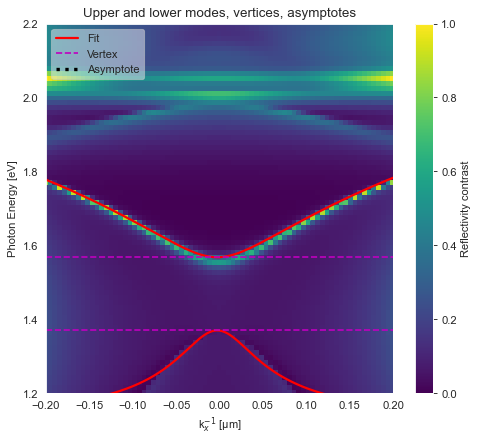

In [107]:
def fitted_to_graph(array: list | float, N: int = N) -> list | float:
    """
    Convert pixel coords/positions to eV given 1.2, 2.2 range, with N length square dimension array
    :param array: list or single number
    :return: new list or number
    """
    max_energy, min_energy = 2.2, 1.2
    min_pixel, max_pixel = 0, N
    energy_values = max_energy - (array - min_pixel) * (max_energy - min_energy) / (max_pixel - min_pixel)
    return energy_values

k_scan_line = np.linspace(-1/kmax, 1/kmax, 300)
x_graphing = np.linspace(0, N+1, 300)
k_scan = np.linspace(-1/kmax, 1/kmax, N)

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,lbda,signalR,cmap='viridis',clim=(0,1))
m1 = r'{-1}'
axs.set(xlabel=f'k$_x^{m1}$ [{greek.mu}m]',xlim=(-1/kmax,1/kmax),ylim=(lbda_max, lbda_min), ylabel='Photon Energy [eV]',title='Upper and lower modes, vertices, asymptotes')
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()



upper_popt = fitting_data['0']['popt']
lower_popt = fitting_data['1']['popt']
upper_fit = hyperbolas[0](x_graphing, *upper_popt)
lower_fit = hyperbolas[1](x_graphing, *lower_popt)


plt.plot(k_scan_line, fitted_to_graph(upper_fit), 'r-', linewidth=2, label='Fit')
plt.plot(k_scan_line, fitted_to_graph(lower_fit), 'r-', linewidth=2)


# def hyperbola_asymptotic(x, a, b, L, M, F, B, sign, V)

vertex = fitted_to_graph(hyperbolas[0](N/2, *upper_popt))
vertex_2 = fitted_to_graph(hyperbolas[1](N/2, *lower_popt))

asym = fitted_to_graph(hyperbolas[0](1e9, *upper_popt))
asym_2 = fitted_to_graph(hyperbolas[1](1e9, *lower_popt))

print(f"\n\nUpper mode (sign -)\n"
      f"Vertex - {vertex:.3f}\nAsymptote - {asym:.3f}\n\n"
      f"Upper mode (sign +)\n"
      f"Vertex - {vertex_2:.3f}\nAsymptote - {asym_2:.3f} \n\n"
      f"DIFF = {abs(vertex-vertex_2):.3f}")

plt.axhline(y=vertex, color='m', linestyle='--', label='Vertex')
plt.axhline(y=vertex_2, color='m', linestyle='--')
plt.axhline(y=asym, color='k', linestyle=':', label='Asymptote', linewidth=3)
plt.axhline(y=asym_2, color='k', linestyle=':', linewidth=3)

plt.legend(loc='upper left', framealpha=0.5)
plt.minorticks_on()
plt.savefig(savepath / 'Fitted modes.png', dpi=150)
plt.show()


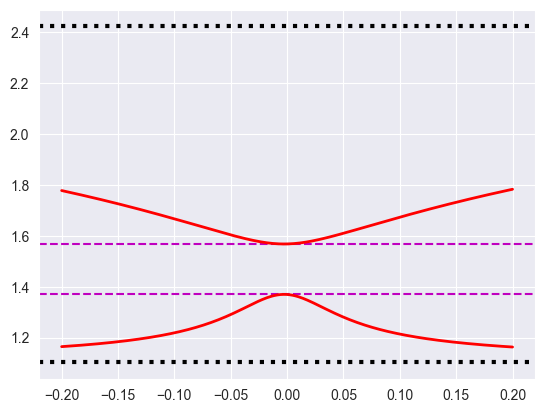

In [106]:
plt.axhline(y=vertex, color='m', linestyle='--', label='Vertex')
plt.axhline(y=vertex_2, color='m', linestyle='--')
plt.axhline(y=asym, color='k', linestyle=':', label='Asymptote', linewidth=3)
plt.axhline(y=asym_2, color='k', linestyle=':', linewidth=3)
plt.plot(k_scan_line, fitted_to_graph(upper_fit), 'r-', linewidth=2, label='Fit')
plt.plot(k_scan_line, fitted_to_graph(lower_fit), 'r-', linewidth=2)

In [95]:
print()